# Momentum gestito per il rischio: risultati

La strategia è il WML (*winners minus losers*): si comprano i titoli del decile con il rendimento passato più alto (vincenti) e si vendono allo scoperto quelli del decile più basso (perdenti). Nella versione gestita il WML è moltiplicato ogni mese per un peso che dipende dalla volatilità prevista. Tutti i termini sono spiegati nella sezione 2 del README.

Questo notebook rilegge i risultati del repository con le stesse funzioni degli script (`src/risk_managed_momentum`). Non sceglie niente di nuovo: il test 2012-2026 è stato eseguito una volta con `scripts/04_test_fuori_campione.py` e il suo esito è in `docs/esito_test.txt`.

Servono gli otto zip di French in `data/raw` (vedi `scripts/00_scarica_dati.py`).

In [1]:
import sys
from pathlib import Path

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RADICE / "src"))

import pandas as pd
from IPython.display import Image, display

from risk_managed_momentum import configurazione as cfg
from risk_managed_momentum import dati, esame, grafici, misure, serie

pd.set_option("display.precision", 3)
OUT = RADICE / "output"
OUT.mkdir(exist_ok=True)
tabella, pesi = serie.costruisci(dati.carica())

## 1. La regola in una riga

Peso del mese t = 12% / volatilità annua prevista, con la volatilità stimata dai 126 rendimenti giornalieri del WML fino alla fine del mese t-1. Quando il momentum è agitato il peso scende, quando è calmo sale (senza tetto).

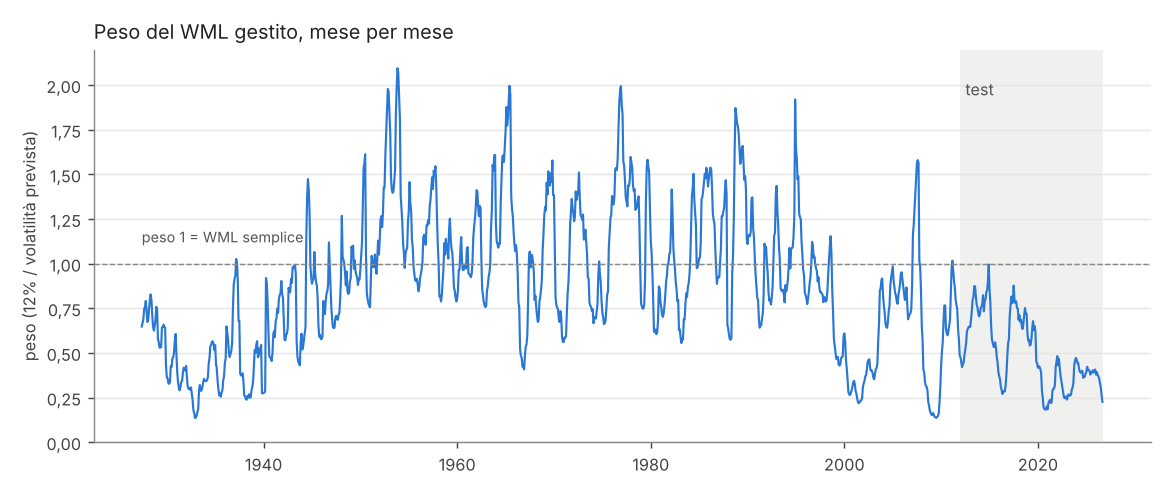

In [2]:
grafici.peso(pesi["wml"].dropna(), cfg.TEST_INIZIO, OUT / "peso_nel_tempo.png")
display(Image(filename=OUT / "peso_nel_tempo.png"))

## 2. Replica del paper (1927-2011)

Serve a controllare il codice: gli Sharpe devono tornare entro ±0,10 da 0,53 e 0,97.

In [3]:
replica = serie.finestra(tabella, None, "2011-12-31", ["wml", "wml_gestita"])
misure.tabella({esame.NOMI[c]: replica[c] for c in replica.columns})[["mesi", "media", "volatilita", "sharpe", "curtosi", "mese_peggiore", "drawdown"]]

,mesi,media,volatilita,sharpe,curtosi,mese_peggiore,drawdown
WML semplice,1016.0,0.149,0.274,0.542,17.950,-0.777,-0.956
WML gestito,1016.0,0.167,0.168,0.996,1.998,-0.242,-0.438


## 3. Test fuori campione (gennaio 2012 - agosto 2026)

Stesse regole, nessun parametro della strategia scelto da me. Il verdetto segue `docs/criteri_del_verdetto.md`.

In [4]:
righe, risultati = esame.analisi(tabella, pesi, cfg.TEST_INIZIO, cfg.TEST_FINE, cfg.SOTTOPERIODI,
                                 cfg.BOOTSTRAP, cfg.RITARDI_NEWEY_WEST)
v = risultati["verdetto"]
print("Ipotesi 1 (rischio):", "confermata" if v["ipotesi_1"] else "non confermata", v["rischio"])
d = v["differenza"]
print(f"Ipotesi 2 (Sharpe): {v['ipotesi_2']}, differenza {d['stima']:+.3f}, IC95 [{d['basso']:+.3f}; {d['alto']:+.3f}]")

Ipotesi 1 (rischio): confermata {'drawdown': True, 'mese_peggiore': True, 'curtosi': True}
Ipotesi 2 (Sharpe): evidenza di miglioramento, differenza +0.177, IC95 [+0.003; +0.333]


In [5]:
x = risultati["x"]
misure.tabella({esame.NOMI[c]: x[c] for c in esame.NOMI})[["media", "volatilita", "sharpe", "curtosi", "mese_peggiore", "drawdown"]]

,media,volatilita,sharpe,curtosi,mese_peggiore,drawdown
WML semplice,0.057,0.289,0.197,2.098,-0.321,-0.648
WML gestito,0.046,0.122,0.375,1.051,-0.125,-0.230
Mom di French,0.024,0.133,0.181,2.264,-0.162,-0.254
Mom gestito,0.044,0.114,0.384,0.771,-0.097,-0.186
Vincenti solo lunghi,0.178,0.215,0.829,2.906,-0.158,-0.313
Vincenti gestiti,0.093,0.111,0.841,1.781,-0.108,-0.140
Mercato,0.136,0.145,0.937,0.970,-0.134,-0.253
Mercato + WML gestito,0.181,0.164,1.107,0.796,-0.125,-0.188


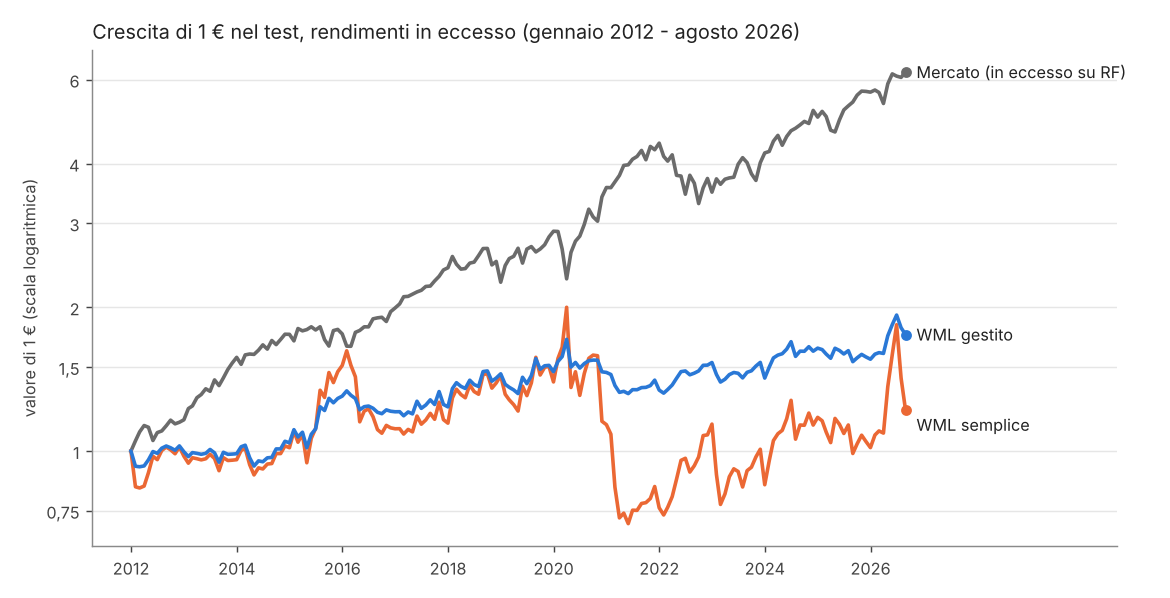

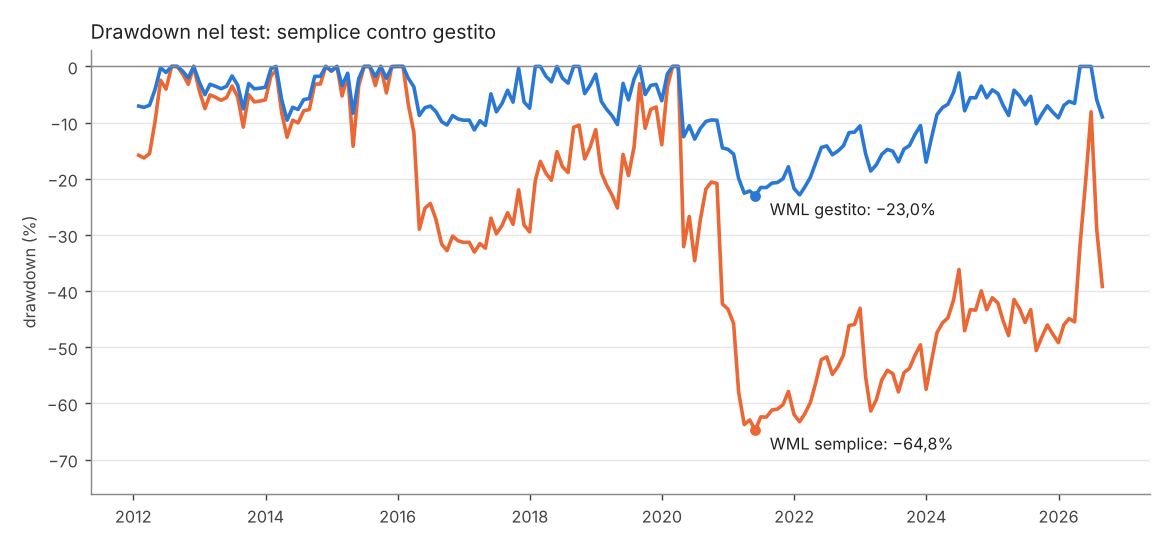

In [6]:
grafici.capitale(x, OUT / "capitale_test.png", "Crescita di 1 € nel test, rendimenti in eccesso (gennaio 2012 - agosto 2026)")
grafici.drawdown(x, OUT / "drawdown_test.png", "Drawdown nel test: semplice contro gestito")
display(Image(filename=OUT / "capitale_test.png"))
display(Image(filename=OUT / "drawdown_test.png"))

## 4. Dove nasce il miglioramento

I mesi peggiori del momentum semplice arrivano quando la volatilità prevista è già alta, quindi il peso è già basso. In quattro casi su cinque il mercato rimbalza e i titoli perdenti (la gamba corta) salgono molto più dei vincenti; a luglio 2026 invece crollano i vincenti.

Un confronto più severo: il semplice ridotto con una costante alla stessa volatilità del gestito (scelta a posteriori). Così si separa il "quanto" rischio dal "quando".

In [7]:
peggiori = x["wml"].nsmallest(5).index
decili = dati.carica().decili_m
display(pd.DataFrame({"semplice": x.loc[peggiori, "wml"], "peso": risultati["pesi"].loc[peggiori, "wml"],
                      "gestito": x.loc[peggiori, "wml_gestita"], "mercato": x.loc[peggiori, "mercato"],
                      "vincenti": decili.loc[peggiori, dati.VINCENTI], "perdenti": decili.loc[peggiori, dati.PERDENTI]}))
k = x["wml_gestita"].std() / x["wml"].std()
misure.tabella({"WML semplice": x["wml"], f"WML semplice x {k:.3f}": k * x["wml"],
                "WML gestito": x["wml_gestita"]})[["volatilita", "sharpe", "curtosi", "mese_peggiore", "drawdown"]]

,semplice,peso,gestito,mercato,vincenti,perdenti
data,,,,,,
2020-04-30,-0.321,0.390,-0.125,0.136,0.147,0.468
2020-11-30,-0.271,0.201,-0.054,0.124,0.104,0.375
2026-07-31,-0.227,0.261,-0.059,-0.006,-0.154,0.073
2021-02-28,-0.226,0.229,-0.052,0.028,-0.028,0.198
2023-01-31,-0.216,0.259,-0.056,0.066,0.005,0.221


,volatilita,sharpe,curtosi,mese_peggiore,drawdown
WML semplice,0.289,0.197,2.098,-0.321,-0.648
WML semplice x 0.423,0.122,0.197,2.098,-0.136,-0.327
WML gestito,0.122,0.375,1.051,-0.125,-0.230


## 5. Sottoperiodi e costi

Il miglioramento dello Sharpe viene dal 2016-2026; nel 2012-2015 le due versioni si equivalgono. Con i costi ipotizzati la differenza resta positiva ma l'intervallo include lo zero, e nello scenario alto il lungo-corto non rende.

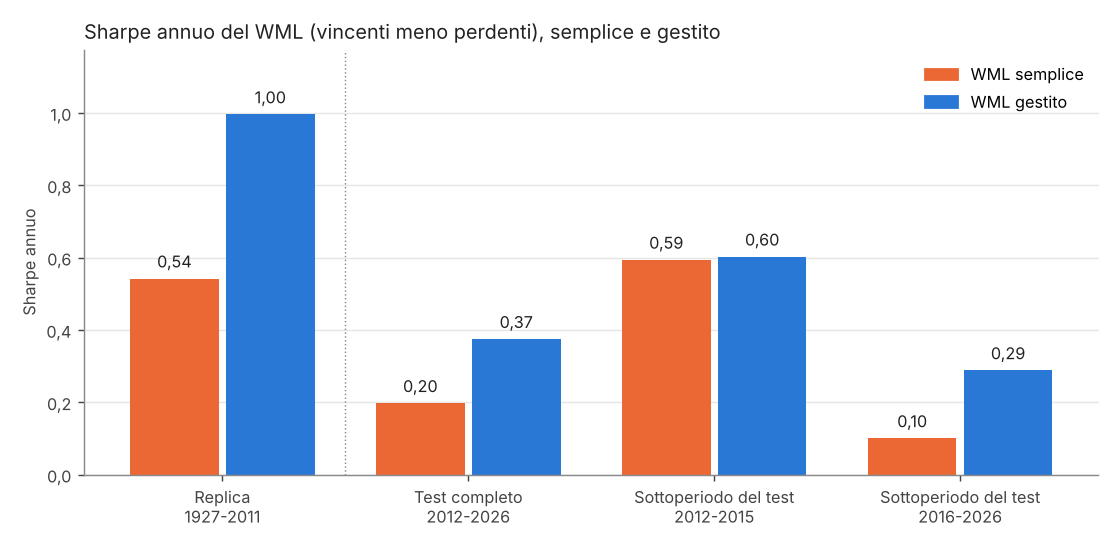

,lordo,medio,alto
WML semplice,0.197,0.041,-0.114
WML gestito,0.375,0.185,-0.004
Vincenti solo lunghi,0.829,0.736,0.643
Vincenti gestiti,0.841,0.733,0.625


In [8]:
valori = {
    "Replica\n1927-2011": {n: misure.sharpe(replica[n]) for n in ("wml", "wml_gestita")},
    "Test completo\n2012-2026": {n: misure.sharpe(x[n]) for n in ("wml", "wml_gestita")},
    **{f"Sottoperiodo del test\n{a[:4]}-{b[:4]}": {n: misure.sharpe(x.loc[a:b, n]) for n in ("wml", "wml_gestita")}
       for a, b in cfg.SOTTOPERIODI},
}
grafici.sharpe_periodi(valori, OUT / "sharpe_per_periodo.png")
display(Image(filename=OUT / "sharpe_per_periodo.png"))
pd.DataFrame({scen: {esame.NOMI[k]: misure.sharpe(s) for k, s in n.items()} for scen, n in risultati["netti"].items()})